# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
## **Práctica 5: Introducción al análisis frecuencial de señales**
### Laboratorio Bioseñales y sistemas
- Alejandra Hinestroza Chaparro
- María José Ríos Hurtado

### **RESUMEN**

<div align ="justify">

El análisis de bioseñales es una herramienta fundamental para la interpretación de procesos fisiológicos. Dado que la mayoría de estas señales son de naturaleza analógica (tiempo continuo), su procesamiento mediante herramientas computacionales como Python requiere una transición al dominio discreto.

El objetivo principal de esta práctica es realizar un acercamiento a los conceptos fundamentales del análisis frecuencial de señales y su aplicación específica en el estudio de bioseñales como el electrocardiograma (ECG) y el electroencefalograma (EEG). A través de esta experimentación, se buscó comprender cómo la representación de una señal en el dominio de la frecuencia permite extraer información relevante que no es evidente en el dominio del tiempo, facilitando tareas como la identificación de componentes rítmicos y la eliminación de ruido.

Para ello, se trabajó con una señal de ECG sobre la cual se aplicó el periodograma de Welch con ventana Hanning, lo que permitió identificar un componente de ruido de interferencia eléctrica a 60 Hz. Dicho ruido fue eliminado mediante el filtrado en el dominio de la frecuencia, utilizando la Transformada de Fourier (FFT) para anular los coeficientes fuera del rango fisiológico de interés, y posteriormente se reconstruyó la señal limpia mediante la Transformada Inversa de Fourier (IFFT). La efectividad del filtrado fue verificada comparando los periodogramas antes y después del proceso.

Adicionalmente, se realizó un análisis comparativo de señales EEG del canal 8 entre un paciente sano y un paciente con enfermedad de Parkinson, empleando nuevamente el método de Welch. Este análisis permitió observar el comportamiento espectral característico de ambas señales en las bandas delta, theta, alfa y beta, identificando similitudes y diferencias en la distribución de potencia que pueden asociarse con las alteraciones neurológicas propias de la enfermedad.

</div>

### **MARCO TEORÍCO**

<duv align ="justify">

**Señales en Tiempo Discreto y Muestreo:**

Para que una señal analógica pueda ser procesada digitalmente, debe someterse a un proceso de muestreo, que consiste en tomar valores de la señal en intervalos regulares de tiempo. Matemáticamente, esto se expresa como x(n)= x (nT), donde T es el período de muestreo. El inverso de este valor, Fs = 1/T, es la frecuencia de muestreo y determina cuántas muestras por segundo se capturan de la señal original.



**Energía y Potencia en el Dominio del Tiempo:**

La caracterización de una señal en el tiempo incluye el cálculo de su energía, la cual en un ciclo de una señal discreta x(n) se halla sumando el cuadrado de sus valores. A partir de esta, se puede obtener la potencia media dividiendo la energía por el número de muestras (menos uno), y el valor eficaz o RMS mediante la raíz cuadrada de la potencia. Estos parámetros son esenciales para cuantificar la magnitud de la actividad fisiológica registrada.

**Transformada Discreta de Fourier (DFT)**

El análisis en frecuencia se basa en la Transformada Discreta de Fourier (DFT), que permite descomponer una señal en sus componentes sinusoidales. En la práctica, se utiliza el algoritmo de la Transformada Rápida de Fourier (FFT) por su eficiencia computacional. Un aspecto clave de la DFT de señales reales es su simetría circularmente par, lo que implica que la información relevante se encuentra contenida en la primera mitad del espectro, hasta la denominada frecuencia de Nyquist (Fs/2).

Para relacionar los índices k del vector resultante de la DFT con frecuencias físicas en hercios (Hz), se utiliza la relación: 

$${F} = {Nk}{Fs}$$

donde N es el número total de muestras

**Estimación Espectral y Método de Welch**

Para señales de larga duración o con características estocásticas, el uso de una sola ventana para calcular la DFT puede no ser representativo. Como alternativa, se emplean los periodogramas, que estiman el contenido de potencia en diferentes frecuencias. El método de Welch mejora esta estimación al dividir la señal en segmentos (ventanas), calcular la densidad espectral de potencia en cada uno mediante el desplazamiento de estas ventanas y, finalmente, promediar los resultados. El uso de ventanas específicas, como la ventana Hanning, y el manejo del solapamiento (overlap) entre segmentos son cruciales para equilibrar la resolución frecuencial y reducir la varianza del estimador.

### **DESARROLLO**

In [114]:
# Librerias necesarias

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import welch as pwelch

**1. Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente. (10%)**

El Teorema de Nyquist dice que para poder representar correctamente una señal sin distorsionarla, la frecuencia de muestreo debe ser al menos el doble de la frecuencia más alta que contiene la señal.

La frecuencia más alta de las tres componentes solicitadas es 160 Hz, entonces:

_**Fs_mínima =** 2 × 160 = 320 Hz_

Pero en la práctica siempre se usa un poco más para tener margen. Se usará _**Fs = 2000 Hz**_, equivalente a 12.5 veces la frecuencia más alta de la señal (160 Hz), lo que garantiza una representación visual suave y cumple ampliamente el criterio de Nyquist con un margen de seguridad adecuado.

Cada sinusoide tiene su propio período:

- **F₁ =** 40 Hz → T₁ = 1/40 = 0.025 s
- **F₂ =** 80 Hz → T₂ = 1/80 = 0.0125 s
- **F₃ =** 160 Hz → T₃ = 1/160 = 0.00625 s

Para que la señal combinada "cierre" un ciclo completo, se usará el período de la componente más lenta (40 Hz), porque las otras dos caben exactamente dentro de él (80 Hz cabe 2 veces, 160 Hz cabe 4 veces).

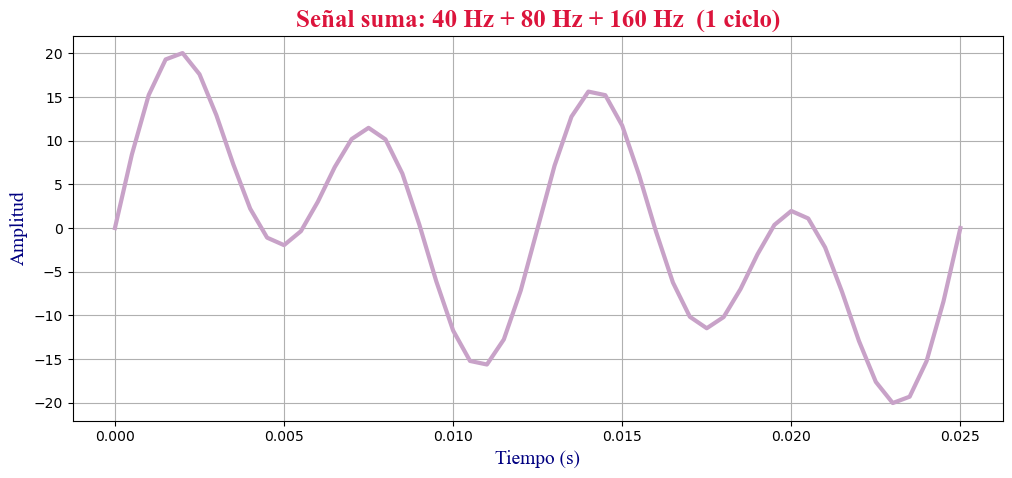

In [116]:

# ── Frecuencias de cada componente sinusoidal ──
F1 = 40    # Hz
F2 = 80    # Hz
F3 = 160   # Hz

# ── Frecuencia de muestreo ──
# Nyquist exige Fs > 2 * 160 = 320 Hz
# Usamos 2000 Hz para tener buena resolución y números cómodos
Fs = 2000          # Hz
T  = 1 / Fs        # Período de muestreo = 0.001 s (tiempo entre muestras)

# ── Período de la señal completa ──
# La componente más lenta marca el período del conjunto
Tp = 1 / F1        # = 0.025 s (un ciclo completo de 40 Hz)

# ── Vector de tiempo para UN ciclo ──
# np.arange(inicio, fin, paso)
# Empezamos en 0, terminamos en Tp (inclusivo), con pasos de T
t = np.arange(0, Tp + T, T)

# ── Construcción de cada sinusoide ──
# La fórmula es: A * sin(2π * F * t)
# Usamos deferentes amplitudes
x1 = 5*np.sin(2 * np.pi * F1 * t)   # componente de 40 Hz
x2 = 8*np.sin(2 * np.pi * F2 * t)   # componente de 80 Hz
x3 = 12*np.sin(2 * np.pi * F3 * t)   # componente de 160 Hz

# ── Señal total: sumamos las tres ──
x = x1 + x2 + x3

# ── Graficamos ──
plt.figure(figsize=(12, 5))
plt.plot(t, x, linewidth=3, color=(200/255, 162/255, 200/255))
plt.title('Señal suma: 40 Hz + 80 Hz + 160 Hz  (1 ciclo)', fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Tiempo (s)', fontname = 'Times New Roman', fontsize = 14,color = "navy")
plt.ylabel('Amplitud', fontname = 'Times New Roman', fontsize = 14,color = "navy")
plt.grid(True)
plt.show()

**4.2 Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal). (10%)**



Número de muestras en 10 ciclos: 501


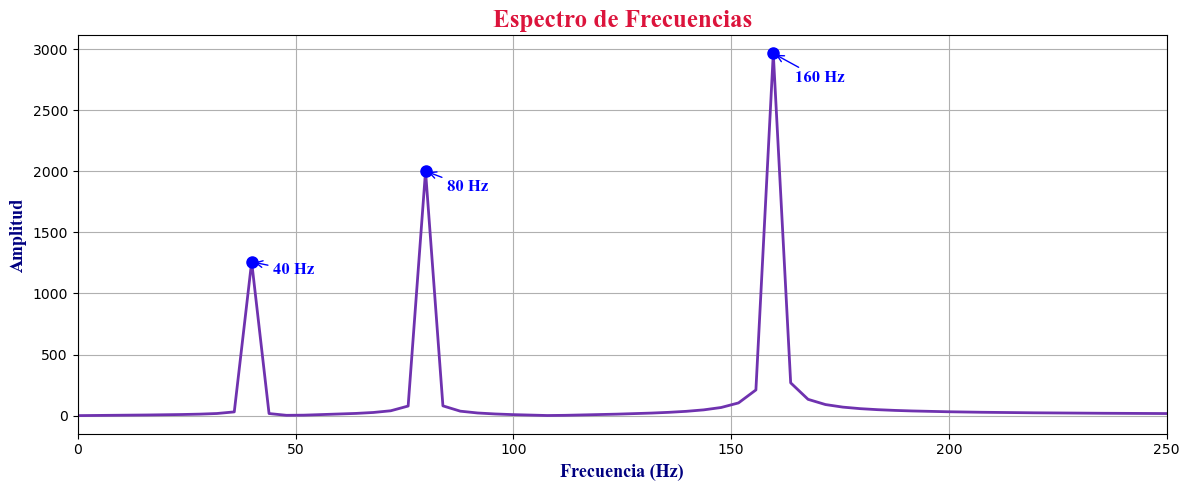

Frecuencias identificadas en el espectro:
───────────────────────────────────
  → 39.9 Hz  |  Amplitud: 1258.84
  → 79.8 Hz  |  Amplitud: 2001.19
  → 159.7 Hz  |  Amplitud: 2964.63


In [118]:
from scipy.signal import find_peaks
# ── Crear la señal con 10 periodos ──
# Antes teníamos 1 ciclo (duración = Tp = 0.025 s)
# Ahora queremos 10 ciclos (duración = 10 * Tp = 0.25 s)

t10 = np.arange(0, 10*Tp + T, T)   # vector de tiempo para 10 ciclos

# Recreamos la señal suma pero ahora con 10 ciclos
x10 = (5*np.sin(2 * np.pi * F1 * t10) +
       8*np.sin(2 * np.pi * F2 * t10) +
       12*np.sin(2 * np.pi * F3 * t10))

print(f'Número de muestras en 10 ciclos: {len(t10)}')

# ── Calcular la DFT ──
X10 = np.fft.fft(x10)
# X10 es un vector de números complejos
# Para graficar usamos su MÓDULO (np.abs), que representa la amplitud

N = len(X10)   # número total de puntos de la DFT

# ── Crear el eje de frecuencias ──
# Cada índice k de la DFT corresponde a una frecuencia F = k * Fs / N
F_eje = np.arange(0, N) * Fs / N

# ── Solo graficamos la mitad (hasta Nyquist) ──
# La DFT es simétrica: la segunda mitad es espejo de la primera
# Solo nos interesa de 0 Hz hasta Fs/2 
Nmitad   = int(np.ceil(N / 2))
F_mitad  = F_eje[:Nmitad]
X_mitad  = X10[:Nmitad]

# ── Encontrar los picos automáticamente ──
# height=50 significa que solo detecta picos que superen esa amplitud
# así evitamos detectar "ruido" pequeño como pico
picos_idx, _ = find_peaks(np.abs(X_mitad), height=50)

# ── Graficar el espectro ──
plt.figure(figsize=(12, 5))
plt.plot(F_mitad, np.abs(X_mitad), color="#6F32AF", linewidth=2)

# ── Etiquetar cada pico encontrado ──
for idx in picos_idx:
    frecuencia = F_mitad[idx]
    amplitud   = np.abs(X_mitad[idx])
    
    # Punto rojo encima del pico
    plt.plot(frecuencia, amplitud, 'bo', markersize=8)
    
    # Etiqueta con la frecuencia
    plt.annotate(f'{frecuencia:.0f} Hz',
                 xy=(frecuencia, amplitud),        # donde apunta la flecha
                 xytext=(frecuencia + 5, amplitud * 0.92),  # donde va el texto
                 fontname='Times New Roman',
                 fontsize=12,
                 fontweight='bold',
                 color='blue',
                 arrowprops=dict(arrowstyle='->', color='blue'))

plt.title('Espectro de Frecuencias',
          fontname='Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Frecuencia (Hz)', fontname='Times New Roman', fontsize=13, fontweight='bold',color = "navy")
plt.ylabel('Amplitud',        fontname='Times New Roman', fontsize=13, fontweight='bold',color = "navy")
plt.xlim(0, 250) # Zoom para ver mejor los picos
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Imprimir en consola ──
print('Frecuencias identificadas en el espectro:')
print('─' * 35)
for idx in picos_idx:
    print(f'  → {F_mitad[idx]:.1f} Hz  |  Amplitud: {np.abs(X_mitad[idx]):.2f}')

**4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior. (10%)**

La Transformada Inversa de Fourier (IFFT, por sus siglas en inglés) es la operación matemática que permite reconstruir una señal en el dominio del tiempo a partir de su representación en el dominio de la frecuencia. En Python, esta operación se implementa mediante la función **_numpy.fft.ifft()_**, la cual recibe como argumento el espectro complejo obtenido por la FFT y devuelve la señal reconstruida. Dado que los cálculos computacionales introducen pequeños errores de redondeo del orden de 10⁻¹⁵, el resultado puede contener una parte imaginaria despreciable, por lo que se extrae únicamente la parte real mediante **_numpy.real()_**. Si la señal original es real y el espectro fue calculado correctamente, la señal reconstruida debe ser numéricamente idéntica a la original, lo cual puede verificarse con la función **_numpy.allclose()_**. [1]

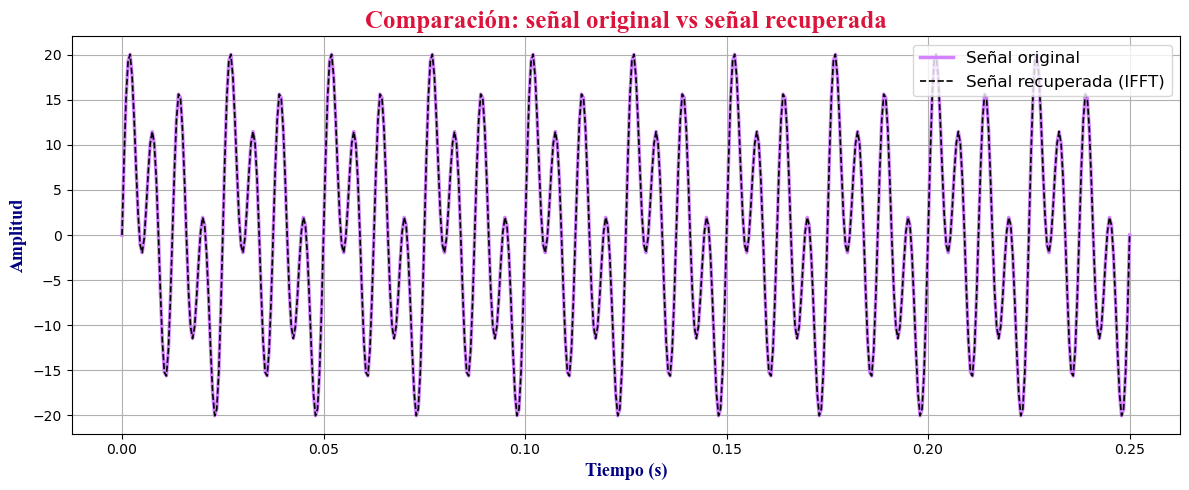

¿La señal recuperada es igual a la original? True


In [122]:
# ── Aplicar la transformada inversa ──
# Le pasamos el espectro completo X10 (no la mitad)
# porque la IFFT necesita toda la información para reconstruir
x_recuperada = np.fft.ifft(X10)

# ── Tomar solo la parte real ──
# El resultado tiene una parte imaginaria pequeñísima
# (del orden de 10^-15) causada por errores de redondeo del computador
# En teoría debería ser cero, así que la descartamos
x_recuperada = np.real(x_recuperada)

# ── Comparar visualmente con la señal original ──
plt.figure(figsize=(12, 5))

# Graficamos la señal original
plt.plot(t10, x10,
         color="#D381FF", linewidth=2.5,
         label='Señal original')

# Graficamos la señal recuperada encima (con línea punteada)
plt.plot(t10, x_recuperada,
         color='black', linewidth=1.2,
         linestyle='--', label='Señal recuperada (IFFT)')

plt.title('Comparación: señal original vs señal recuperada',
          fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Tiempo (s)', fontname='Times New Roman', fontsize=13, fontweight='bold',color = "navy")
plt.ylabel('Amplitud',   fontname='Times New Roman', fontsize=13, fontweight='bold',color = "navy")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Verificar numéricamente que son iguales ──
# np.allclose compara dos arreglos elemento por elemento
# y devuelve True si todos son prácticamente iguales
son_iguales = np.allclose(x10, x_recuperada)
print(f'¿La señal recuperada es igual a la original? {son_iguales}')

**4.4 ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué? (10%)**

_F1 = np.fft.fft(x);_ 

_F2 = np.zeros((len(F1)));_

_F2[9:13] = F1[9:13];_ 

_xr = np.fft.ifft(F2);_

_fig = plt.figure()_

_ax = fig.add_subplot(111)_

_ax.plot(t, np.real(xr))_

_ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');_

_plt.show()_

**Extraiga de manera similar cada una de las componentes de la señal.**

El código presentado implementa un filtro pasa-banda en el dominio de la frecuencia. Mediante la FFT se obtiene el espectro completo de la señal, luego se construye un vector de ceros del mismo tamaño y se copian únicamente los coeficientes espectrales correspondientes a los índices 9 a 12, anulando el resto. Al aplicar la IFFT sobre este espectro modificado, se obtiene una señal reconstruida que contiene exclusivamente las componentes frecuenciales seleccionadas. Este procedimiento es equivalente a multiplicar el espectro por una función rectangular (ventana) centrada en la banda de interés, lo cual es la definición de un filtro ideal pasa-banda [2].

Índices de nuestras frecuencias:
────────────────────────────────────────
  40  Hz  →  k = 1
  80  Hz  →  k = 2
  160 Hz  →  k = 4


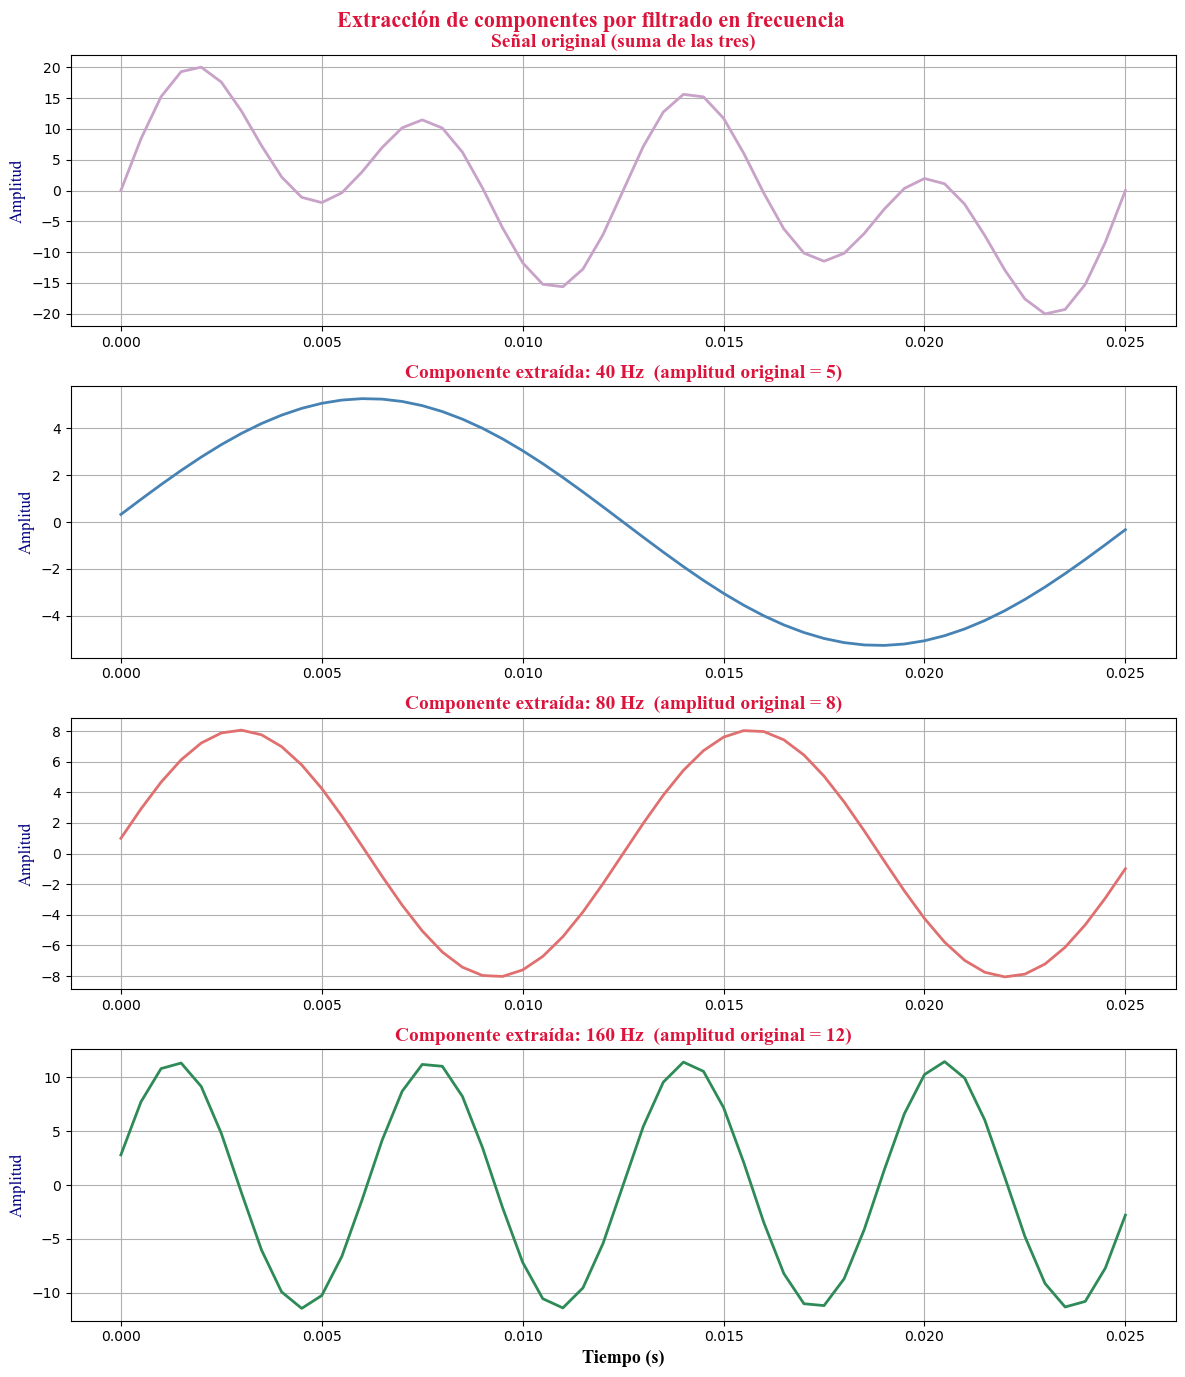

Verificación de amplitudes extraídas:
────────────────────────────────────────
  40  Hz  →  amplitud recuperada: 5.27  (esperada: 5)
  80  Hz  →  amplitud recuperada: 8.06  (esperada: 8)
  160 Hz  →  amplitud recuperada: 11.47  (esperada: 12)


In [123]:
# ── Calcular la FFT de la señal de 1 ciclo ──
FFT_x = np.fft.fft(x)
N_x   = len(FFT_x)    # número de muestras de la señal

# ── Calcular los índices correctos para nuestras frecuencias ──
# Con Fs=2000 Hz, los índices cambian respecto a la guía
k_40  = int(round(F1 * N_x / Fs))
k_80  = int(round(F2 * N_x / Fs))
k_160 = int(round(F3 * N_x / Fs))

print('Índices de nuestras frecuencias:')
print('─' * 40)
print(f'  40  Hz  →  k = {k_40}')
print(f'  80  Hz  →  k = {k_80}')
print(f'  160 Hz  →  k = {k_160}')

# ── Extraer componente de 40 Hz ──
# Creamos vector de ceros tipo complex porque la FFT es compleja
F_filtro_40             = np.zeros(N_x, dtype=complex)
F_filtro_40[k_40]       = FFT_x[k_40]          # lado izquierdo del espectro
F_filtro_40[N_x - k_40] = FFT_x[N_x - k_40]   # lado derecho (simetría)
comp_40 = np.real(np.fft.ifft(F_filtro_40))

# ── Extraer componente de 80 Hz ──
F_filtro_80             = np.zeros(N_x, dtype=complex)
F_filtro_80[k_80]       = FFT_x[k_80]
F_filtro_80[N_x - k_80] = FFT_x[N_x - k_80]
comp_80 = np.real(np.fft.ifft(F_filtro_80))

# ── Extraer componente de 160 Hz ──
F_filtro_160              = np.zeros(N_x, dtype=complex)
F_filtro_160[k_160]       = FFT_x[k_160]
F_filtro_160[N_x - k_160] = FFT_x[N_x - k_160]
comp_160 = np.real(np.fft.ifft(F_filtro_160))

fig, axes = plt.subplots(4, 1, figsize=(12, 14))

# Señal original arriba para comparar
axes[0].plot(t, x, color='#C8A2C8', linewidth=2)
axes[0].set_title('Señal original (suma de las tres)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold',color = "crimson")
axes[0].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12,color = "navy")
axes[0].grid(True)

# Componente 40 Hz
axes[1].plot(t, comp_40, color='steelblue', linewidth=2)
axes[1].set_title('Componente extraída: 40 Hz  (amplitud original = 5)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold', color = "crimson")
axes[1].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12,color = "navy")
axes[1].grid(True)

# Componente 80 Hz
axes[2].plot(t, comp_80, color='#E07070', linewidth=2)
axes[2].set_title('Componente extraída: 80 Hz  (amplitud original = 8)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold', color = "crimson")
axes[2].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12,color = "navy" )
axes[2].grid(True)

# Componente 160 Hz
axes[3].plot(t, comp_160, color='seagreen', linewidth=2)
axes[3].set_title('Componente extraída: 160 Hz  (amplitud original = 12)',
                  fontname='Times New Roman', fontsize=14, fontweight='bold', color = "crimson")
axes[3].set_ylabel('Amplitud', fontname='Times New Roman', fontsize=12,color = "navy")
axes[3].set_xlabel('Tiempo (s)', fontname='Times New Roman', fontsize=13, fontweight='bold')
axes[3].grid(True)

plt.suptitle('Extracción de componentes por filtrado en frecuencia',
             fontname='Times New Roman', fontsize=16, fontweight='bold',color = "crimson")
plt.tight_layout()
plt.show()

# ── Verificar que las amplitudes son correctas ──
print('Verificación de amplitudes extraídas:')
print('─' * 40)
print(f'  40  Hz  →  amplitud recuperada: {np.max(np.abs(comp_40)):.2f}  (esperada: 5)')
print(f'  80  Hz  →  amplitud recuperada: {np.max(np.abs(comp_80)):.2f}  (esperada: 8)')
print(f'  160 Hz  →  amplitud recuperada: {np.max(np.abs(comp_160)):.2f}  (esperada: 12)')

**4.5 El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventana) (25%)** 

In [38]:
# Cargamos la señal e identificamos su estructura para saber cómo acceder a los datos

señal = loadmat ('senecg.mat')
print(señal.keys()) #Para ver las llaves de la señal cargada, así sabemos cómo acceder a los datos

ECG = señal['ECG'].flatten()


dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


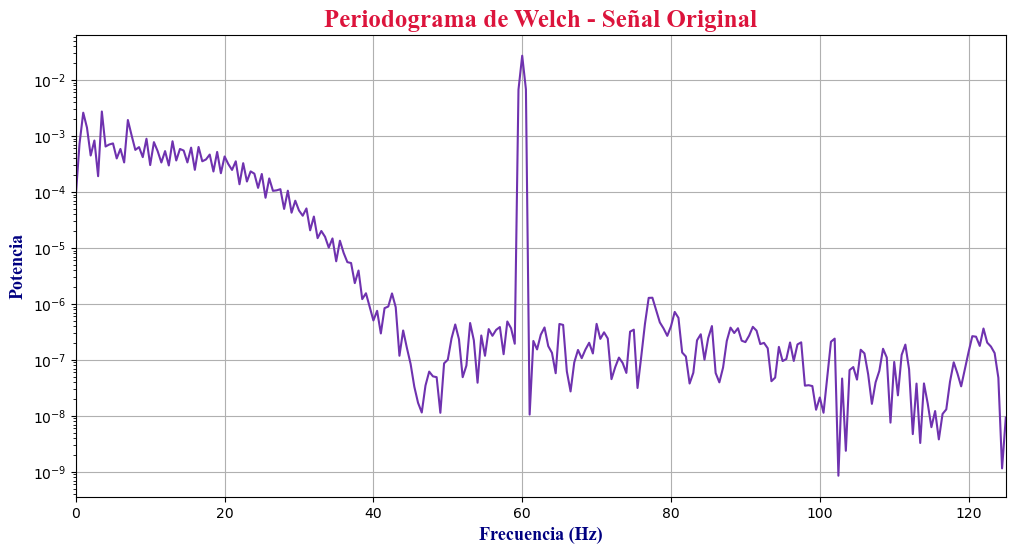

In [124]:
#Teniendo en cuenta la frecuencia de muestreo:

Fs = 250 
N = len(ECG)
t = np.arange(0, N) / Fs # Eje de tiempo

# Análisis inicial - Periodograma de Welch

# Usamos la  función pwelch para identificar componentes de ruido

nperseg = 500  # Ancho de ventana: 2 segundos de señal para buena resolución
noverlap = int (nperseg/2) # Solapamiento al 50% para reducir varianza

f, Pxx = pwelch(ECG [0:500], Fs, 'hann', nperseg, noverlap)

# Graficamos Frecuencia vs Potencia 

plt.figure(figsize=(12, 6))
plt.semilogy(f, Pxx, color = "#6F32AF") # Escala logarítmica para ver mejor el ruido
plt.title('Periodograma de Welch - Señal Original',fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Frecuencia (Hz)',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.ylabel('Potencia',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.xlim(0, 125) # Solo hasta Nyquist
plt.grid(True)
plt.show()


<div align = "justify">

**Análisis Espectral con el Periodograma de Welch:** Para el análisis frecuencial de la señal ECG se utilizó el periodograma de Welch, método que estima la densidad espectral de potencia promediando los espectros de múltiples ventanas desplazadas sobre la señal, lo que reduce la varianza de la estimación en comparación con una FFT directa.

**Justificación de los Parámetros de Welch:** Se seleccionaron los siguientes parámetros con base en las características de la señal:

- Ventana Hanning: Se eligió para minimizar el spectral leakage. A diferencia de una ventana rectangular, la Hanning atenúa suavemente los extremos de cada segmento, evitando que la energía de un componente frecuencial se disperse hacia las frecuencias adyacentes. Esto permite observar picos espectrales con mayor precisión y definición.

- Ancho de ventana (nperseg = 500 muestras): Con una frecuencia de muestreo de Fs=250, este valor proporciona una resolución frecuencial de Δf = Fs/N = 0.5 , suficiente para identificar con detalle las bandas de interés del ECG.

- Solapamiento del 50% (noverlap): La ventana Hanning atenúa los bordes de cada segmento, por lo que sin solapamiento se perdería información en esas zonas. Se elige solapamiento del 50% que permite recuperar información, reducir la varianza global de la estimación y producir una curva espectral más suave y representativa de la señal fisiológica.

**Identificación del Ruido:** Al observar el periodograma de la señal original, se identificó un pico agudo y predominante en  60 Hz, lo cual corresponde a interferencia de la red eléctrica. Este componente no pertenece a la actividad eléctrica del corazón, cuya información fisiológica útil se concentra en el rango de 0.5 Hz a 45 Hz. En el dominio del tiempo, este ruido se manifiesta como una oscilación rápida superpuesta sobre la señal cardíaca , lo que confirma la necesidad de aplicar un proceso de filtrado.

</div>

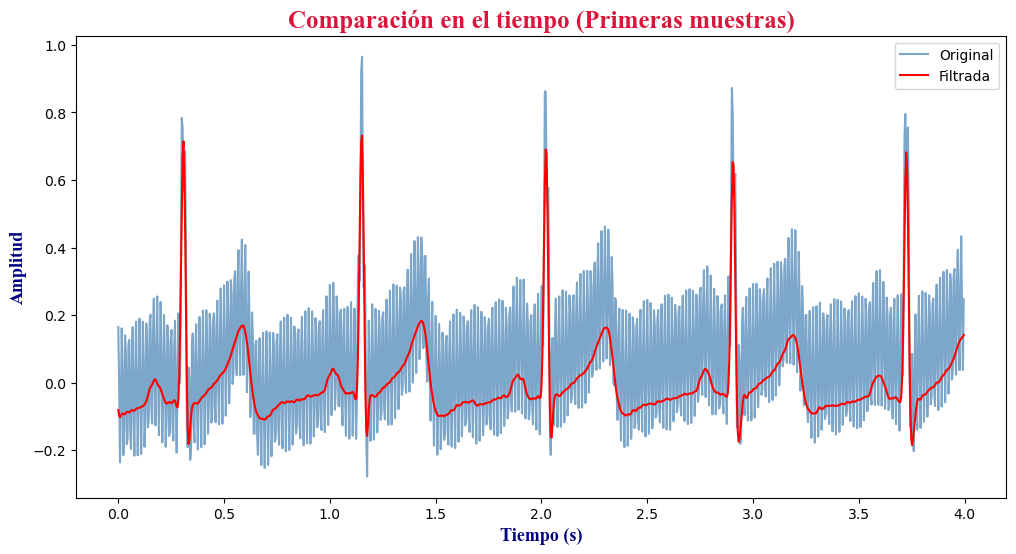

In [125]:
# Filtrado en Frecuencia

# Siguiendo la técnica del punto 4.4, aplicamos la FFT, eliminamos las frecuencias no deseadas (ruido) poniendo sus coeficientes en cero y aplicamos la inversa.

# Calculamos la FFT de la señal original

F1 = np.fft.fft(ECG)

# Creamos un vector de ceros para el filtrado 

F2 = np.zeros(len(F1), dtype=complex)

# Definimos el rango de paso (Frecuencias del ECG: aprox 0.5 a 45 Hz) y Calculamos los índices k correspondientes usando F = (k * Fs) / N [5]

f_min, f_max = 0.5, 45
k_min = int(f_min * N / Fs)
k_max = int(f_max * N / Fs)

# Dejamos los componentes de baja frecuencia y su simetría 

F2[k_min:k_max] = F1[k_min:k_max] # Parte positiva
F2[-k_max:-k_min] = F1[-k_max:-k_min] # Parte negativa (espejo)

# Aplicamos la transformada inversa para obtener la señal filtrada 

ECG_filtrado = np.fft.ifft(F2)
ECG_filtrado = np.real(ECG_filtrado) # Para extraer la parte real 

# Comprobamos los resultados visualmente y con el periodograma de Welch para la señal filtrada

# Comparación en el Tiempo

plt.figure(figsize=(12, 6))
plt.plot(t[:1000], ECG[:1000], label='Original', alpha=0.7, color = "steelblue")
plt.plot(t[:1000], ECG_filtrado[:1000], label='Filtrada', color='red')
plt.legend()
plt.title('Comparación en el tiempo (Primeras muestras)',fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Tiempo (s)',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.ylabel('Amplitud',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.show()


**Filtrado mediante FFT**

<div align = "justify">
El procedimiento de eliminación de ruido se realizó en el dominio de la frecuencia siguiendo estos pasos:

  1. Transformada de Fourier (FFT): Se llevó la señal original al dominio frecuencial mediante np.fft.fft.

  2. Filtrado por anulación de coeficientes: Se construyó un vector de ceros del mismo tamaño que la FFT y se copiaron únicamente los coeficientes correspondientes al rango de interés (0.5 Hz – 45 Hz), eliminando así toda componente fuera de ese intervalo.

  3. Transformada Inversa (IFFT): Se aplicó np.fft.ifft al espectro filtrado para reconstruir la señal en el dominio del tiempo.

En la imagen, se observa la señal de ECG original (en azul) contaminada por ruido de alta frecuencia, posiblemente interferencia de la red eléctrica de 60 Hz o ruido muscular, y una ligera inestabilidad en la línea base. Tras el procesamiento, la señal filtrada (en rojo) mantiene los componentes fisiológicos esenciales, como el complejo QRS, pero con una apariencia mucho más suave y limpia, lo que confirma la efectividad de la eliminación de componentes no deseados.

</div>

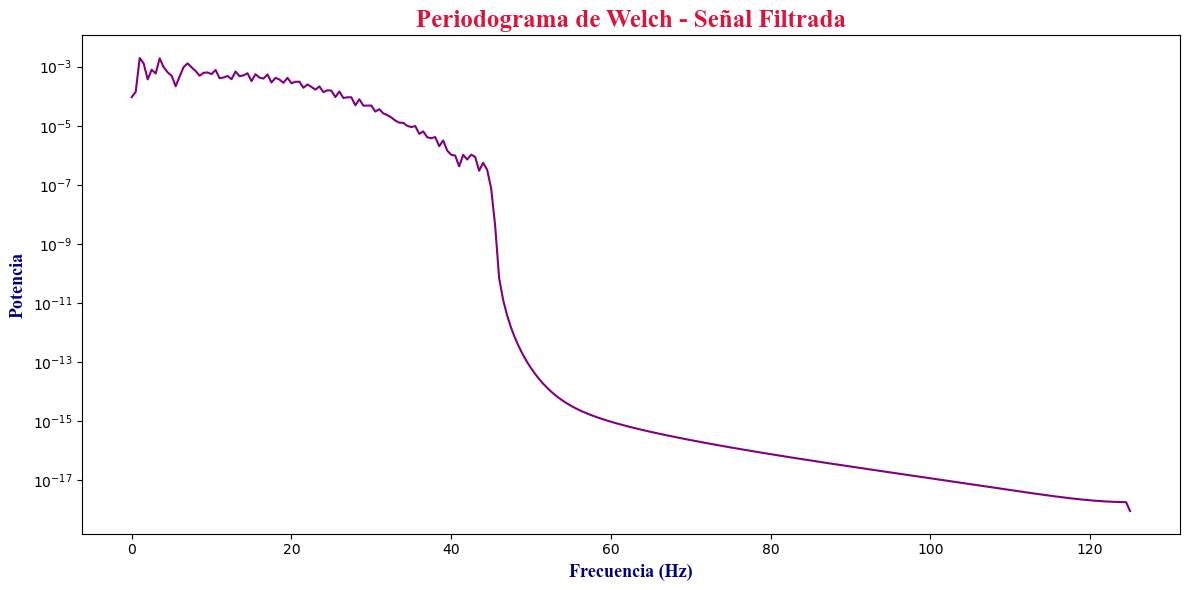

In [126]:
# Verificación con Periodograma

f_filt, Pxx_filt = pwelch(ECG_filtrado, Fs, 'hann', nperseg, noverlap)

plt.figure(figsize=(12, 6))
plt.semilogy(f_filt, Pxx_filt, color='purple')
plt.title('Periodograma de Welch - Señal Filtrada',fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Frecuencia (Hz)',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.ylabel('Potencia',fontname = 'Times New Roman', fontsize = 13, fontweight='bold',color = "navy")
plt.tight_layout()
plt.show()

**Comprobación del Filtrado**

La efectividad del filtrado se verificó de dos formas:

- En el dominio del tiempo: La señal reconstruida (en rojo) muestra la forma de onda cardíaca limpia, sin las oscilaciones rápidas presentes en la señal original.

- En el dominio de la frecuencia: El periodograma de Welch de la señal filtrada confirma que el pico de 60 Hz ha desaparecido por completo, y la potencia fuera del rango 0.5–45 Hz cae a niveles despreciables (del orden de $10^{-17}$), evidenciando que el ruido fue eliminado sin comprometer la información fisiológica de interés.

**4.6 Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventana) (25%)**

In [ ]:
# Cargamos los datos e identificamos su estructura 

parkinson_raw = loadmat("parkinson/P001_EP_reposo.mat")
control_raw = loadmat("control/C001R_EP_reposo.mat")

print(parkinson_raw.keys())
print(control_raw.keys())

# Ver la forma original sin modificar
data_sano = control_raw['data']
data_park = parkinson_raw['data']

print(f"Shape sano: {data_sano.shape}")
print(f"Shape park: {data_park.shape}")

dict_keys(['__header__', '__version__', '__globals__', 'data'])
dict_keys(['__header__', '__version__', '__globals__', 'data'])
Shape sano: (8, 2000, 180)
Shape park: (8, 2000, 143)


In [104]:
from scipy.io import loadmat
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

# Recargar sin aplanar
data_sano_raw = loadmat("control/C001R_EP_reposo.mat")['data']   # shape: (8, 2000, 143)
data_park_raw = loadmat("parkinson/P001_EP_reposo.mat")['data']  # shape: (8, 2000, 180)

print(f"Shape sano: {data_sano_raw.shape}")
print(f"Shape park: {data_park_raw.shape}")


Shape sano: (8, 2000, 180)
Shape park: (8, 2000, 143)


Shape segmento sano: (2000,)
Shape segmento park: (2000,)


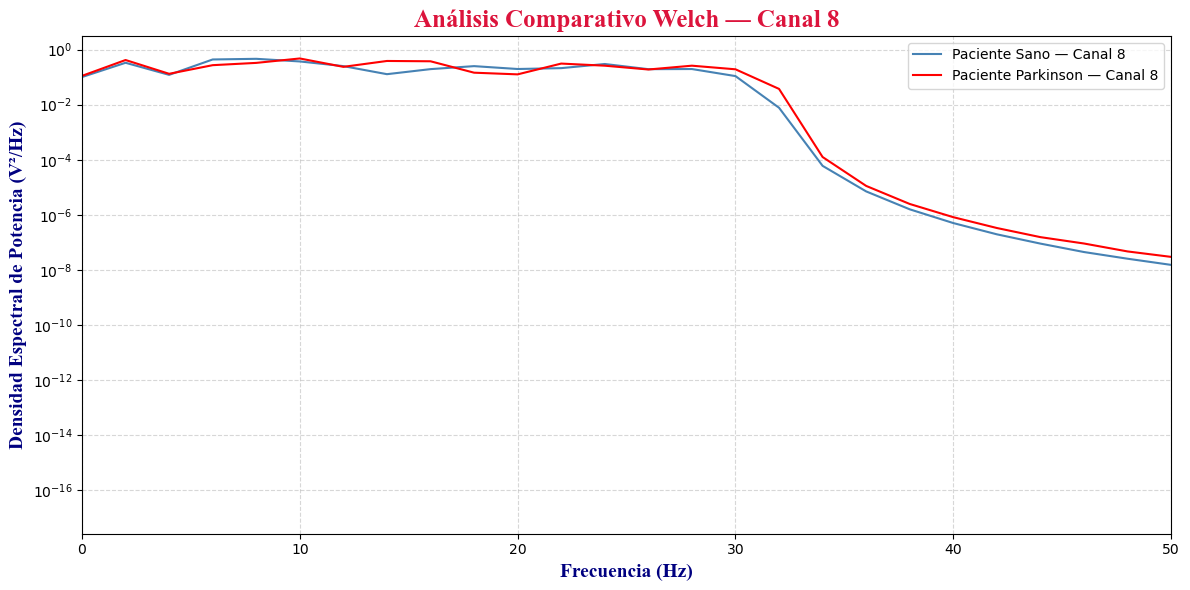

In [127]:
fs = 1000
idx = 7  # Canal 8

# Usamos un solo segmento representativo (el del medio)

seg_medio_sano = data_sano_raw[idx, :, 90]   # segmento 90 de 180
seg_medio_park = data_park_raw[idx, :, 71]   # segmento 71 de 143

print(f"Shape segmento sano: {seg_medio_sano.shape}")  # debe ser (2000,)
print(f"Shape segmento park: {seg_medio_park.shape}")  # debe ser (2000,)

f_sano, Pxx_sano = welch(seg_medio_sano, fs=fs, window='hann', nperseg=500, noverlap=250)
f_park, Pxx_park = welch(seg_medio_park, fs=fs, window='hann', nperseg=500, noverlap=250)

plt.figure(figsize=(12, 6))
plt.plot(f_sano, Pxx_sano, label='Paciente Sano — Canal 8', color='steelblue')
plt.plot(f_park, Pxx_park, label='Paciente Parkinson — Canal 8', color='red')
plt.title('Análisis Comparativo Welch — Canal 8', fontname = 'Times New Roman', fontsize = 18, fontweight='bold',color = "crimson")
plt.xlabel('Frecuencia (Hz)', fontsize=14, color='navy',font = "Times New Roman",fontweight='bold')
plt.ylabel('Densidad Espectral de Potencia (V²/Hz)', fontsize=14,color='navy',font = "Times New Roman",fontweight='bold')
plt.xlim(0, 50)
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Parámetros de Welch Ventana Hanning**
<div align = "justify">

- Se seleccionó la ventana Hanning para minimizar el spectral leakage. Al atenuar suavemente los extremos de cada segmento, se evita que la energía de una componente frecuencial se disperse hacia las frecuencias adyacentes. Esto es especialmente importante en señales EEG, donde las bandas de interés (delta, theta, alfa, beta) están muy próximas entre sí y una contaminación entre bandas dificultaría su correcta identificación.

- Ancho de ventana (nperseg = 500 muestras):Con una frecuencia de muestreo de Fs​=1000 Hz, este valor proporciona una resolución frecuencial de:
$${Δf = \frac{Fs}{N} =  \frac{1000}{500} = 2 Hz}$$
Esta resolución es adecuada para distinguir las bandas fisiológicas del EEG (delta, theta, alfa, beta), que tienen anchos de banda de al menos 4 Hz cada una. Además, dado que cada segmento tiene 2000 muestras, usar nperseg = 500 permite dividir cada segmento en múltiples ventanas, lo que mejora el promediado estadístico del método de Welch y produce un espectro más estable.

- Solapamiento del 50% (noverlap = 250 muestras): La ventana Hanning atenúa los extremos de cada segmento, lo que significa que las muestras en los bordes contribuyen menos al espectro. Sin solapamiento, esta información se perdería. Un solapamiento del 50% garantiza que cada muestra de la señal quede bien representada en al menos una ventana con peso significativo, reduciendo la varianza de la estimación sin incrementar excesivamente el costo computacional. Este valor del 50% es el estándar recomendado para la ventana Hanning.

</div>

Ambas señales presentan el comportamiento espectral típico de una señal EEG: potencia elevada en frecuencias bajas que decae progresivamente hacia las frecuencias altas, con una caída drástica a partir de los 30–35 Hz.

### **ANÁLISIS DE RESULTADOS Y DISCUSIÓN**

<div align= "justify">

**Análisis Comparativo de la señal ECG dada**

Al observar el Periodograma de Welch - Señal Original, se identifica una interferencia crítica: un pico de potencia extremadamente agudo y prominente localizado exactamente en los 60 Hz. Este componente no es de origen fisiológico, sino que representa la interferencia de la red eléctrica que contamina el registro del ECG.

En la Comparación en el tiempo, este ruido se manifiesta como una oscilación rápida (rizado) superpuesta a la señal de interés (curva azul), la cual dificulta la visualización clara de las ondas P, T y el segmento ST. Por lo tanto, se determinó que es necesario eliminar este ruido para permitir una visualización correcta de la señal fisilogica de interes.

La efectividad del proceso se comprueba mediante el Periodograma de Welch - Señal Filtrada. En esa imagen se observa que el pico de 60 Hz ha sido eliminado por completo, y la potencia cae drásticamente después de los 45 Hz, alcanzando niveles de ruido de fondo insignificantes (10 −17 V²/Hz). La señal reconstruida en el tiempo mantiene la morfología esencial del corazón pero sin las perturbaciones de alta frecuencia detectadas inicialmente.

**Análisis en Frecuencia Parkinson vs Control**

- Banda Delta (0.5–4 Hz): Ambos pacientes muestran potencia similar en esta banda, con valores alrededor de 10010^{0} 100 V²/Hz. No se observan diferencias significativas entre el paciente sano y el paciente con Parkinson en esta región.

- Banda Theta (4–8 Hz): Se aprecia una leve caída en ambas señales alrededor de los 4–5 Hz, seguida de una recuperación hacia los 8–10 Hz. El comportamiento es prácticamente idéntico entre ambos pacientes en este rango.

- Banda Alfa (8–13 Hz): Se observa un pico de potencia alrededor de los 10 Hz en ambas señales, ligeramente más pronunciado en el paciente sano. Esta banda está asociada con estados de relajación y es típicamente más prominente en sujetos sanos.

- Banda Beta (13–30 Hz): Ambas señales mantienen una potencia relativamente estable y similar hasta los 30 Hz, sin diferencias marcadas. A partir de aquí comienza la caída abrupta del espectro.

- Por encima de 30 Hz: A partir de los 30–35 Hz se produce una caída pronunciada de varios órdenes de magnitud en ambas señales. El paciente sano (azul) muestra una potencia ligeramente mayor que el paciente con Parkinson (rojo) en el rango de 30–50 Hz, lo que podría indicar mayor actividad en banda gamma en el sujeto sano.

</div>

### **CONCLUSIONES**

<div align ="justify">

- El análisis frecuencial mediante periodogramas de Welch permite extraer información y conclusiones de la señal original que no son evidentes en el dominio del tiempo, facilitando la identificación de ruidos específicos como la interferencia de linea.

- La combinación de FFT e IFFT constituye una herramienta poderosa de filtrado, permitiendo "limpiar" el espectro de la señal de manera selectiva antes de su reconstrucción.

- El uso de ventanas no rectangulares (como Hanning) y el solapamiento de segmentos son estrategias técnicas indispensables para obtener estimaciones de potencia confiables y con baja varianza en bioseñales de larga duración.

- En cuanto a las señales parkinson y control análizadas en el canal 8, ambas señales son espectralmente muy similares en este canal y segmento analizado, lo que sugiere que un solo segmento puede no ser suficiente para capturar diferencias estadísticamente representativas entre ambos grupos. La diferencia más notable se encuentra en frecuencias superiores a 30 Hz, donde el paciente sano presenta mayor potencia. Para un análisis más robusto sería recomendable promediar el espectro sobre todos los segmentos disponibles.

- La práctica demuestra que la digitalización y el procesamiento computacional son pasos críticos para convertir señales fisiológicas analógicas en datos interpretables y libres de artefactos técnicos.

</div>

### _Referencias_

[1] NumPy Developers. (2024). numpy.fft.ifft. NumPy Documentation. https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html

[2] J. G. Proakis, D.G. Manolakis, Digital Signal Processing. Principles and Applications, 4th ed, pag. 75-77, Ed. Prentice Hall, 2007.